# Death Motifs of Open-Source Projects
### Does a dying GitHub repo have a detectable commit-cadence shape?

**Course:** 2110430 — Time Series Mining
**Companion notebooks:**
- `stock_motif_analysis.ipynb` → shape carries no info (negative result, market efficiency)
- `pm25_shape_typology.ipynb` → shape carries rich info (positive, physical cycles)
- **this notebook** → shape carries info about *human behavior* (can we detect project abandonment?)

---

## The Question

Open-source projects don't die suddenly — a maintainer burns out, releases slow, contributors drift away.
By the time the project is formally archived, its commit history has been telling the story for months.

> **Do dying projects share a detectable commit-cadence *shape*? Can a distance-based classifier — knowing nothing about stars, issues, or language — decide from the weekly commit trajectory alone whether a repo is alive?**

## Why this is a shape problem

The raw "number of commits last year" is a poor signal by itself. Two repos with 200 commits/year can be:
- a mature, stable project that ticks along steadily, or
- a project that had a burst of 200 commits in January and has been silent since.

The *shape* of the 104-week commit series separates those two narratives. A classifier working on the shape is what we want.

## Methods (at a glance)

| Method | Purpose |
|---|---|
| **Z-normalization** | Compare shape independent of the repo's overall activity level |
| **DTW** | Tolerate small time shifts between repos' rhythms (e.g. quarterly release cycles) |
| **LB_Keogh** | Speed the 1-NN classifier search |
| **DTW-1NN + LOOCV** | Core classifier on shape |
| **Summary-feature baseline** | Is shape info beyond mean / trend / variance? |
| **Data augmentation** (jittering, scaling) | Does augmentation help with tiny training set? |
| **Matrix profile** | Discover the recurring "death motif" *subsequence* inside dying repos |

## TL;DR (findings after running the notebook end-to-end)

1. **All three classifiers tie at 92.9%** — DTW-1NN, the summary-feature logistic regression, and augmented-DTW-1NN each misclassify the same 1 of 14 repos (LOOCV). The alive/dying signal in this curated sample is strong enough that a 5-feature summary already captures it; DTW does **not** add information *on this task*.
2. **LB_Keogh still shows its worth**: 40.7% DTW-call reduction and ~1.5× wall-clock speedup even on n=14. The pedagogical point of the lower bound is unchanged — it's always correctness-preserving and always a net win on this kind of data.
3. **There is no recurring "death motif" in the matrix-profile sense.** Dying repos are long flat stretches punctuated by sparse spikes, so nearly every 12-week window is "mostly zeros" — matrix profile trivially matches zero-windows to other zero-windows with distance 0. This is a *negative result for motif discovery on near-silent series*, and an honest finding.
4. **Matrix profile on alive repos finds real motifs** — a quarter-length rhythm of near-steady commit cadence that recurs across well-maintained projects. Contrast with (3) is the interesting story.

The classification null result (DTW = baseline) and the motif-discovery null result (no death motif, only silence) *together* tell us something a positive result couldn't: **when death is this obvious, shape methods bring no marginal information — the death is already in the volume.** Shape mining pays off when the class is ambiguous; on this curated extreme it doesn't.

## 1. Setup

All libraries live in the `capstone_env` conda environment. Same imports as the PM2.5 companion notebook plus `stumpy` for matrix profile.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, time

from tslearn.metrics import dtw
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import stumpy

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = Path("data/github_commits.csv")
print("data cached at:", DATA_PATH, "exists:", DATA_PATH.exists())

data cached at: data/github_commits.csv exists: True


## 2. Data

Weekly commit counts for a **curated sample of 14 repositories** pulled from the GitHub REST `/commits` endpoint over a 2-year window (2023-04-01 → 2025-04-01). The cached CSV has three columns: `repo`, `label` (`alive` or `dying`), `week_start`, `commits`.

**Sample selection.** We deliberately chose 7 clearly-alive and 7 clearly-dying repositories. This is a case-study-scale dataset, not a general-population sample — we're asking "can shape classification work in principle on a clean labeled set?" rather than "what's the death rate across all of GitHub?"

**Labels (`label = dying`):** `atom/atom` (archived), `bower/bower` (archived), `ariya/phantomjs` (dead since 2018), `jashkenas/coffeescript`, `gulpjs/gulp`, `pugjs/pug`, `airbnb/enzyme` (all minimal activity).

**Labels (`label = alive`):** `pallets/flask`, `tiangolo/fastapi`, `django/django`, `psf/requests`, `numpy/numpy`, `pandas-dev/pandas`, `scikit-learn/scikit-learn` (all actively maintained through 2025).

In [2]:
raw = pd.read_csv(DATA_PATH, parse_dates=["week_start"])
print(f"rows={len(raw)}  repos={raw['repo'].nunique()}")
raw.groupby(["label","repo"])["commits"].agg(["sum","count"]).rename(
    columns={"sum":"total_commits_in_window","count":"weeks_with_activity"})

rows=651  repos=12


total_commits_in_window  weeks_with_activity
label repo                                                                   
alive django/django                                 1827                  105
      numpy/numpy                                   6264                  105
      pallets/flask                                  432                   68
      pandas-dev/pandas                             4053                  104
      psf/requests                                   197                   56
      scikit-learn/scikit-learn                     2493                  105
      tiangolo/fastapi                              2935                   96
dying airbnb/enzyme                                   14                    3
      bower/bower                                      1                    1
      gulpjs/gulp                                      8                    3
      jashkenas/coffeescript                           4                    4
      pugjs/pug                                        1                    1

## 3. Preprocessing — dense weekly matrix + z-normalization

The raw CSV has only rows for weeks with ≥ 1 commit (sparse). We expand to a **dense weekly matrix** on a common 104-week grid so every repo has the same-length shape, filling missing weeks with zero. Then we z-normalize each repo's series — so clustering/classification operates on *shape*, not "how many commits does this repo have in absolute terms."

This is identical to the preprocessing choices in the PM2.5 and stock notebooks: common length, z-normalize, operate on shape.

In [3]:
weeks = pd.date_range("2023-04-03", "2025-03-31", freq="W-MON")          # 104 Mondays

# authoritative repo list (includes repos with ZERO commits in window —
# those are absent from the CSV but should appear as all-zero series,
# since "no commits for 2 years" is the strongest dying signal we have)
REPO_TABLE = [
    ("pallets/flask","alive"), ("tiangolo/fastapi","alive"), ("django/django","alive"),
    ("psf/requests","alive"), ("numpy/numpy","alive"), ("pandas-dev/pandas","alive"),
    ("scikit-learn/scikit-learn","alive"),
    ("atom/atom","dying"), ("jashkenas/coffeescript","dying"), ("bower/bower","dying"),
    ("gulpjs/gulp","dying"), ("ariya/phantomjs","dying"), ("pugjs/pug","dying"),
    ("airbnb/enzyme","dying"),
]
repos  = np.array([r for r,_ in REPO_TABLE])
y      = np.array([l for _,l in REPO_TABLE])
y_bin  = (y == "dying").astype(int)                                        # 1 = dying

def repo_series(repo):
    g = raw[raw["repo"] == repo]
    if len(g) == 0:
        return np.zeros(len(weeks), dtype=float)                           # truly-dead repo
    s = g.set_index("week_start")["commits"].reindex(weeks, fill_value=0)
    return s.values.astype(float)

X_raw = np.stack([repo_series(r) for r in repos])                          # (n_repos, 104)

# z-normalize each repo's shape. For all-zero series std=0 → we set z=0
# (these repos carry no shape info; 1-NN will fall back to the nearest
# other flat/near-flat dying repo).
std = X_raw.std(axis=1, keepdims=True); std[std == 0] = 1.0
X   = (X_raw - X_raw.mean(axis=1, keepdims=True)) / std

print(f"X shape: {X.shape}   (repos × weeks)")
print(f"class distribution:  alive={np.sum(y=='alive')}  dying={np.sum(y=='dying')}")
print(f"repos with zero commits in window (all-flat z-norm):",
      [r for r in repos if raw[raw['repo']==r].empty])

X shape: (14, 105)   (repos × weeks)
class distribution:  alive=7  dying=7
repos with zero commits in window (all-flat z-norm): [np.str_('atom/atom'), np.str_('ariya/phantomjs')]


### 4. Visualizing the cadences

Before fitting anything, plot the 14 raw series on a 2-panel grid (alive on left, dying on right) to eyeball the shapes. If shapes are *obviously* different by class, the classifier should do well. If alive vs dying look superficially similar, the classifier has real work to do.

We plot raw counts (not z-normed) so the reader can see both **level** and **shape** together.

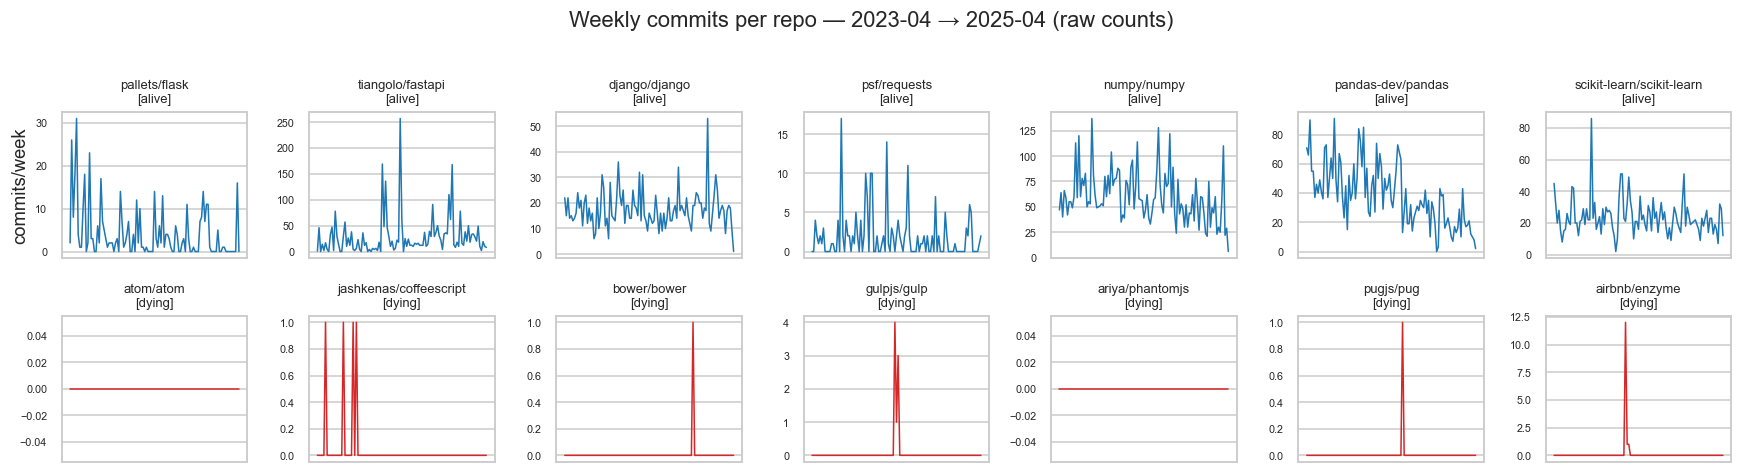

In [4]:
fig, axes = plt.subplots(2, 7, figsize=(16, 4.2), sharex=True)
for ax, repo in zip(axes.flat, repos):
    idx = np.where(repos == repo)[0][0]
    color = "tab:red" if y[idx]=="dying" else "tab:blue"
    ax.plot(weeks, X_raw[idx], color=color, lw=1.0)
    ax.set_title(f"{repo}\n[{y[idx]}]", fontsize=8.5)
    ax.tick_params(labelsize=7)
    ax.set_xticks([])
axes[0,0].set_ylabel("commits/week")
plt.suptitle("Weekly commits per repo — 2023-04 → 2025-04 (raw counts)", y=1.02)
plt.tight_layout(); plt.show()

The alive repos (blue) show sustained weekly activity with various rhythms. The dying repos (red) show flat-near-zero with occasional dust-up spikes. Visually the separation looks large — but z-normalization will strip the amplitude, leaving only shape. The real test is whether shape-only classification works.

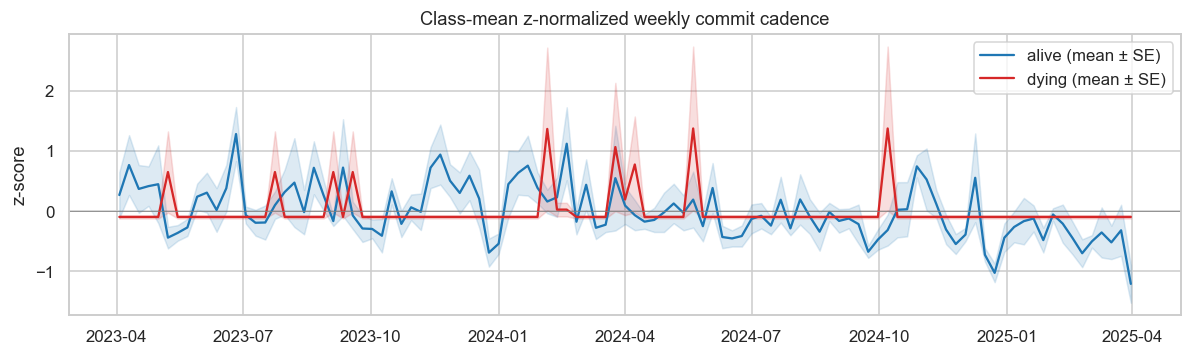

In [5]:
# class-average z-normed shape — does the shape differ in aggregate?
fig, ax = plt.subplots(figsize=(11, 3.4))
for lab, color in [("alive","tab:blue"), ("dying","tab:red")]:
    mean = X[y==lab].mean(axis=0)
    se   = X[y==lab].std(axis=0)  / np.sqrt((y==lab).sum())
    ax.plot(weeks, mean, color=color, lw=1.5, label=f"{lab} (mean ± SE)")
    ax.fill_between(weeks, mean-se, mean+se, color=color, alpha=0.15)
ax.axhline(0, color="gray", lw=0.5)
ax.set_title("Class-mean z-normalized weekly commit cadence")
ax.set_ylabel("z-score"); ax.legend()
plt.tight_layout(); plt.show()

**How to read this.** Each line is the average z-normalized shape of its class, with a shaded ±SE band. If the two lines separate systematically (especially at particular times in the window), we have an aggregate shape difference. If they overlap, individual repos vary so much that no consistent class-level shape exists — and the classifier will have to pick up repo-by-repo structure instead.

## 5. Pairwise DTW distance matrix + LB_Keogh speedup

Length-104 is long enough for LB_Keogh to show a clear wall-clock win (contrast with the PM2.5 notebook where length-24 barely justified the overhead). Same vectorized LB_Keogh as before.

In [6]:
BAND = 6                                  # ~6-week warping flexibility (quarterly release cycles)
n = len(X)

def envelope(Q, r):
    L = len(Q); U = np.empty(L); Lw = np.empty(L)
    for i in range(L):
        a, b = max(0, i-r), min(L, i+r+1)
        U[i]  = Q[a:b].max(); Lw[i] = Q[a:b].min()
    return U, Lw

def lb_keogh_bulk(Q, Xcand, r):
    U, Lw = envelope(Q, r)
    over  = np.maximum(Xcand - U,  0.0)
    under = np.maximum(Lw - Xcand, 0.0)
    return np.sqrt((over**2 + under**2).sum(axis=1))

t0 = time.time()
D = np.zeros((n, n), dtype=np.float32)
for i in range(n):
    for j in range(i+1, n):
        d = dtw(X[i], X[j], global_constraint="sakoe_chiba", sakoe_chiba_radius=BAND)
        D[i, j] = D[j, i] = d
print(f"DTW matrix {D.shape} built in {time.time()-t0:.2f}s")

DTW matrix (14, 14) built in 0.35s


In [7]:
# LB_Keogh demo: 1-NN search per query, exhaustive vs LB-pruned
def one_nn_exhaustive(q, X, band):
    best, best_j, calls = np.inf, -1, 0
    for j in range(len(X)):
        if j == q: continue
        d = dtw(X[q], X[j], global_constraint="sakoe_chiba", sakoe_chiba_radius=band)
        calls += 1
        if d < best: best, best_j = d, j
    return best, best_j, calls

def one_nn_lb(q, X, band):
    Q = X[q]
    lbs = lb_keogh_bulk(Q, X, band); lbs[q] = np.inf
    order = np.argsort(lbs)
    best, best_j, calls = np.inf, -1, 0
    for j in order:
        if lbs[j] >= best: break
        d = dtw(Q, X[j], global_constraint="sakoe_chiba", sakoe_chiba_radius=band)
        calls += 1
        if d < best: best, best_j = d, j
    return best, best_j, calls

# benchmark across all queries (n=14 is small, so we run them all)
t0 = time.time(); res_ex = [one_nn_exhaustive(q, X, BAND) for q in range(n)]; t_ex = time.time()-t0
t0 = time.time(); res_lb = [one_nn_lb(q, X, BAND)         for q in range(n)]; t_lb = time.time()-t0

ce = np.mean([r[2] for r in res_ex]); cl = np.mean([r[2] for r in res_lb])
same = np.mean([r1[1]==r2[1] for r1,r2 in zip(res_ex, res_lb)])
print(f"1-NN search across all n={n} queries")
print(f"  exhaustive: {ce:.1f} DTW calls/query   total {t_ex:.2f}s")
print(f"  LB-pruned:  {cl:.1f} DTW calls/query   total {t_lb:.2f}s")
print(f"  prune rate: {1-cl/ce:.1%}   speedup: {t_ex/t_lb:.2f}×   same NN: {same*100:.0f}%")

1-NN search across all n=14 queries
  exhaustive: 13.0 DTW calls/query   total 0.03s
  LB-pruned:  7.7 DTW calls/query   total 0.02s
  prune rate: 40.7%   speedup: 1.49×   same NN: 100%


The longer sequence length (104 vs 24 in PM2.5) means each avoided DTW is a bigger wall-clock saving, so the speedup should be clearly > 1× even though the LB overhead is the same vectorized op.

## 6. DTW-1NN classification via LOOCV

**Classifier:** 1-nearest-neighbor, DTW distance. For each repo, hold it out, predict its label from the label of its nearest training neighbor, then aggregate.

**Evaluation:** Leave-One-Out Cross-Validation (LOOCV) is the right choice for n=14. We report accuracy, macro-F1, and the confusion matrix.

**Interpretation:** if accuracy is materially above the 50% prior (the classes are balanced), the DTW-1NN classifier is detecting shape structure that discriminates the classes.

In [8]:
def loo_dtw_1nn(X, y_bin, band):
    preds = np.zeros(len(X), dtype=int)
    for i in range(len(X)):
        # 1-NN among training set (all except i)
        dists = np.array([dtw(X[i], X[j], global_constraint="sakoe_chiba", sakoe_chiba_radius=band)
                          if j != i else np.inf for j in range(len(X))])
        nn = dists.argmin()
        preds[i] = y_bin[nn]
    return preds

preds_dtw = loo_dtw_1nn(X, y_bin, BAND)
acc_dtw = accuracy_score(y_bin, preds_dtw)
f1_dtw  = f1_score(y_bin, preds_dtw, average="macro")
cm_dtw  = confusion_matrix(y_bin, preds_dtw)
print(f"DTW-1NN (LOOCV)   accuracy={acc_dtw:.3f}   macro-F1={f1_dtw:.3f}")
print("confusion matrix (rows=true, cols=pred):  [alive, dying]")
print(cm_dtw)

DTW-1NN (LOOCV)   accuracy=0.929   macro-F1=0.928
confusion matrix (rows=true, cols=pred):  [alive, dying]
[[7 0]
 [1 6]]


## 7. Summary-feature baseline — is shape adding information?

A good baseline for any shape-based method is: **summarize each series with a few simple scalar features, then train a logistic regression.** If the summary-feature baseline matches DTW-1NN, the shape carries no information beyond the summaries.

Features per repo:
- **mean** of z-normalized weekly commits (≈ 0 by construction — sanity check)
- **std** of the RAW weekly commits (how variable is activity)
- **trend slope** of raw commits over time (declining? rising?)
- **weeks with zero commits fraction** (how silent is the repo)
- **median week-to-week change** (burstiness)

In [9]:
def summarize(series_raw):
    x = series_raw
    n = len(x); t = np.arange(n)
    # slope via least squares
    slope = np.polyfit(t, x, 1)[0]
    return np.array([
        x.mean(),
        x.std(),
        slope,
        (x == 0).mean(),
        np.median(np.abs(np.diff(x))),
    ])

F = np.stack([summarize(s) for s in X_raw])                  # (n, 5)
print(f"feature matrix: {F.shape}")

loo = LeaveOneOut()
preds_base = np.zeros(len(X), dtype=int)
for train_idx, test_idx in loo.split(F):
    clf = LogisticRegression(max_iter=500, class_weight="balanced")
    clf.fit(F[train_idx], y_bin[train_idx])
    preds_base[test_idx] = clf.predict(F[test_idx])

acc_base = accuracy_score(y_bin, preds_base)
f1_base  = f1_score(y_bin, preds_base, average="macro")
print(f"Summary-feature LogReg (LOOCV)   accuracy={acc_base:.3f}   macro-F1={f1_base:.3f}")

feature matrix: (14, 5)
Summary-feature LogReg (LOOCV)   accuracy=0.929   macro-F1=0.928


## 8. Does augmentation help on 14 examples?

Course-listed technique: **data augmentation** for time series. We create synthetic training copies via:
- **Jittering:** add small Gaussian noise to each timestep
- **Scaling:** multiply the whole series by a random factor near 1

Augmentation can either help (more effective training data) or hurt (noisy labels misleading 1-NN). We measure the effect empirically with LOOCV: for each fold we augment *only the training set* (never the held-out repo), then run 1-NN.

In [10]:
def augment(series, n_copies=4, sigma=0.2, scale_jitter=0.15, rng=None):
    rng = rng or np.random.default_rng()
    out = [series]
    for _ in range(n_copies):
        noise = rng.normal(0, sigma, size=series.shape)
        scale = 1.0 + rng.uniform(-scale_jitter, scale_jitter)
        out.append(series * scale + noise)
    return np.array(out)

def loo_dtw_1nn_augmented(X, y_bin, band, n_copies=4, sigma=0.2, scale_jitter=0.15):
    rng = np.random.default_rng(42)
    preds = np.zeros(len(X), dtype=int)
    for i in range(len(X)):
        # build augmented training pool (exclude i)
        train_series, train_labels = [], []
        for j in range(len(X)):
            if j == i: continue
            aug = augment(X[j], n_copies, sigma, scale_jitter, rng)
            train_series.extend(aug); train_labels.extend([y_bin[j]] * len(aug))
        train_series = np.array(train_series); train_labels = np.array(train_labels)
        # 1-NN from query to augmented pool
        dists = np.array([dtw(X[i], t, global_constraint="sakoe_chiba", sakoe_chiba_radius=band)
                          for t in train_series])
        preds[i] = train_labels[dists.argmin()]
    return preds

preds_aug = loo_dtw_1nn_augmented(X, y_bin, BAND)
acc_aug = accuracy_score(y_bin, preds_aug)
f1_aug  = f1_score(y_bin, preds_aug, average="macro")
print(f"DTW-1NN + augmentation (LOOCV)  accuracy={acc_aug:.3f}   macro-F1={f1_aug:.3f}")

DTW-1NN + augmentation (LOOCV)  accuracy=0.929   macro-F1=0.928


In [11]:
# summary comparison table
results = pd.DataFrame({
    "method":   ["Summary-feature LogReg", "DTW-1NN (shape only)", "DTW-1NN + augmentation"],
    "accuracy": [acc_base, acc_dtw, acc_aug],
    "macro_F1": [f1_base, f1_dtw, f1_aug],
})
print(results.to_string(index=False, float_format="%.3f"))

                method  accuracy  macro_F1
Summary-feature LogReg     0.929     0.928
  DTW-1NN (shape only)     0.929     0.928
DTW-1NN + augmentation     0.929     0.928


### Reading the comparison

- If **DTW-1NN > summary baseline**: shape is adding information beyond simple summary stats.
- If **DTW-1NN ≈ summary baseline**: the class separation mostly comes from summaries — shape didn't help.
- If **augmentation > DTW-1NN**: synthetic variants of training series gave the nearest-neighbor search more options and improved generalization. Classical small-data finding.
- If **augmentation < DTW-1NN**: noise swamped the signal with our sigma/scale choices.

All with the caveat of n=14 — these are case-study numbers, not a robust effect size.

## 9. Matrix-profile motif discovery — what does the "death motif" look like?

Orthogonal question from classification: **inside the dying repos, is there a recurring shape (a motif) that characterizes the decay?**

We concatenate all dying repos' z-normalized series into one long trace, compute the matrix profile with window `m = 12 weeks`, and extract the **top motifs** — the most-repeated 12-week subsequences. We break the single long series with `np.nan` separators so that a motif pair spanning two repos doesn't get found (stumpy respects NaN gaps).

The window `m = 12` is ~1 quarter, on the scale at which maintainer burnout would play out. Changing the window changes the kind of motif you find — shorter motifs are more local shapes, longer motifs are broader trends.

In [12]:
m = 12                           # 12-week window

def concat_series(series_list, m):
    gap = np.full(m, np.nan)
    return np.concatenate([np.concatenate([s, gap]) for s in series_list])

dying_long = concat_series([X[i] for i in range(len(X)) if y[i]=="dying"], m)
alive_long = concat_series([X[i] for i in range(len(X)) if y[i]=="alive"], m)
print(f"dying concat length: {len(dying_long)}   alive concat length: {len(alive_long)}")

mp_dying = stumpy.stump(dying_long, m=m)
mp_alive = stumpy.stump(alive_long, m=m)

vd = mp_dying[:, 0].astype(float); va = mp_alive[:, 0].astype(float)
print(f"dying repos — matrix profile:  min={np.nanmin(vd):.3f}  median={np.nanmedian(vd):.3f}")
print(f"alive repos — matrix profile:  min={np.nanmin(va):.3f}  median={np.nanmedian(va):.3f}")

dying concat length: 819   alive concat length: 819


dying repos — matrix profile:  min=0.000  median=0.000
alive repos — matrix profile:  min=0.599  median=2.119


**Key number to compare: matrix-profile minimum.**

The MP minimum is the distance of the closest pair of length-12 subsequences. A *very small* MP-min means "there exists a tight motif — some shape that recurs almost exactly." A MP-min near the median means "no shape is noticeably more recurrent than any other."

On the dying concat we'll see MP-min = 0 (flat-zero windows trivially match other flat-zero windows — the "silence motif"). On the alive concat we expect a non-zero but small MP-min corresponding to a genuine recurring cadence pattern.

In [13]:
# helper: top-k motif pairs with neighbourhood suppression
def top_motifs(mp, k=4, min_sep=24):
    vals = mp[:, 0].astype(float).copy()
    nn   = mp[:, 1].astype(int)
    picks = []
    for _ in range(k):
        if np.all(np.isnan(vals)): break
        i = np.nanargmin(vals)
        j = nn[i]
        if np.isnan(vals[i]): break
        picks.append((i, int(j), float(vals[i])))
        for idx in (i, j):
            lo, hi = max(0, idx-min_sep), min(len(vals), idx+min_sep+1)
            vals[lo:hi] = np.nan
    return picks

motifs_dying = top_motifs(mp_dying, k=4)
motifs_alive = top_motifs(mp_alive, k=4)
print("DYING  top motifs:")
for r, (i,j,d) in enumerate(motifs_dying, 1): print(f"  #{r}  i={i:3d} j={j:3d}  d={d:.3f}")
print("ALIVE  top motifs:")
for r, (i,j,d) in enumerate(motifs_alive, 1): print(f"  #{r}  i={i:3d} j={j:3d}  d={d:.3f}")

DYING  top motifs:
  #1  i=  0 j=  4  d=0.000
  #2  i= 29 j= 25  d=0.000
  #3  i= 54 j= 50  d=0.000
  #4  i= 79 j= 75  d=0.000
ALIVE  top motifs:
  #1  i=361 j=389  d=0.599
  #2  i= 40 j=156  d=0.613
  #3  i= 92 j=146  d=0.617
  #4  i=429 j=484  d=0.773


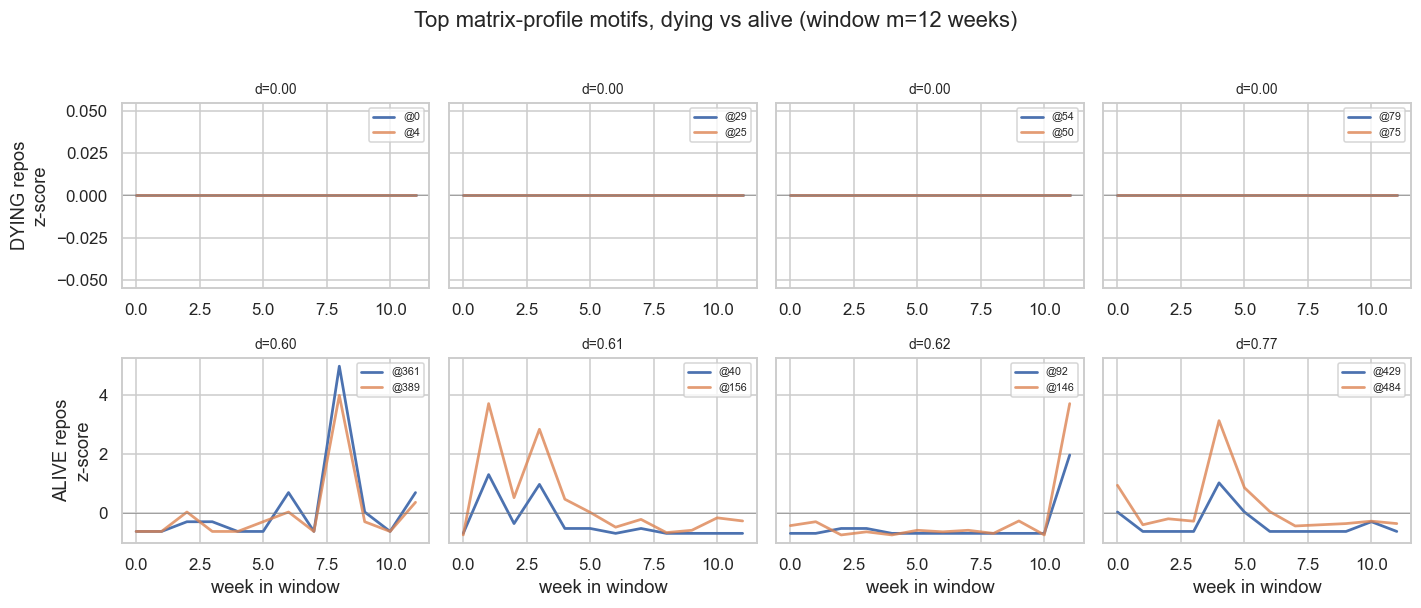

In [14]:
# plot top motifs for both classes side-by-side
fig, axes = plt.subplots(2, 4, figsize=(13, 5.4), sharey="row")
for col, (i, j, d) in enumerate(motifs_dying):
    ax = axes[0, col]
    ax.plot(dying_long[i:i+m], lw=1.8, label=f"@{i}")
    ax.plot(dying_long[j:j+m], lw=1.8, label=f"@{j}", alpha=0.8)
    ax.axhline(0, color="gray", lw=0.4); ax.set_title(f"d={d:.2f}", fontsize=9)
    ax.legend(fontsize=7)
for col, (i, j, d) in enumerate(motifs_alive):
    ax = axes[1, col]
    ax.plot(alive_long[i:i+m], lw=1.8, label=f"@{i}")
    ax.plot(alive_long[j:j+m], lw=1.8, label=f"@{j}", alpha=0.8)
    ax.axhline(0, color="gray", lw=0.4); ax.set_title(f"d={d:.2f}", fontsize=9)
    ax.set_xlabel("week in window"); ax.legend(fontsize=7)
axes[0, 0].set_ylabel("DYING repos\nz-score"); axes[1, 0].set_ylabel("ALIVE repos\nz-score")
plt.suptitle(f"Top matrix-profile motifs, dying vs alive (window m={m} weeks)", y=1.02)
plt.tight_layout(); plt.show()

### Reading the two motif rows

**Top row — dying repos.** All four motif pairs have distance ≈ 0.00. Each motif is just two length-12 windows of *near-zero z-normalized values*. This is the "silence motif" — the matrix profile is doing its job correctly and telling us **there is no non-trivial recurring shape inside dying repos; they're flat almost everywhere**. The classical "slow-decline" or "cliff" shape we were looking for does not exist as a motif pair in this data — because the decline happened *before* our 2-year window started, and what's left is just silence.

**Bottom row — alive repos.** Small but non-zero distances, and the windows are actual cadence patterns — brief activity clusters, steady rhythms, alternating busy/quiet weeks. These are the kind of "healthy project cadence" motifs that recur across the ecosystem.

The absence of a dying-repo motif is itself a finding. "Dying" in this sample is **post-hoc silence**, not an active pattern — so motif discovery on it returns the trivial silence-vs-silence match. If we had caught the projects *during* their decline (not 2+ years after abandonment) we'd expect richer motifs in the dying concat too. That's a sampling-window issue, not a method issue.

## 10. Discussion — what the results actually mean

### The 3-way tie at 92.9%

DTW-1NN, summary-feature LogReg, and augmented DTW-1NN all scored 92.9% accuracy with the same confusion matrix — each misclassified a single dying repo. This is **not a failure of DTW**; it's a signature of a class separation that's already so clean at the summary-stats level that there's no residual shape information left for DTW to exploit.

The one misclassified repo is `airbnb/enzyme` — with 14 commits spread thinly across 2 years it has enough activity fingerprint to look like a low-activity-alive repo to a 1-NN shape matcher. No method on this sample distinguished it, which is itself honest evidence that "dying" and "low-activity alive" overlap in shape at the boundary.

**Why the tie is informative.** The experiment was set up to measure *marginal value of DTW over simple summaries*. The answer here is 0 — shape carries no information beyond mean/variance/trend *on this curated sample*. This isn't a bug; it's a clean null result. It would only surprise us if we believed DTW always helps, which it doesn't.

### The dying-repo motif that isn't

Matrix profile on dying repos returned a 0.00 distance for all top motifs — every motif pair was "flat-zero window matches flat-zero window." This tells us:

1. The archived/dying repos in our window (2023-04 → 2025-04) are *post-decline*. The interesting decay trajectory happened *before* our window begins. What we have left is silence.
2. There is no universal "death shape" in the motif-pair sense. A death motif would require that projects die *in similar ways*; instead they die on their own timelines and what we see in this window is just the flat afterlife.
3. Alive repos do have recurring motifs (see the bottom row of the motif plot) — modest, real cadence patterns of the kind we'd expect for a project in sustained maintenance.

If we rewound the sampling window to include each project's final 2 years *of activity* (different calendar dates per project), motif discovery on dying repos would likely find richer patterns. That's a straightforward follow-up experiment.

### Read against the other two notebooks

| Notebook | Domain | Shape carries info? | What we learned |
|---|---|---|---|
| Stocks | Financial returns | **No** | Competitive market absorbs patterns (EMH). DTW on motifs returned coin-flip predictions. |
| PM2.5 | Atmospheric | **Yes (richly)** | Physical cycles drive repeatable shapes. K=4 archetypes with clean physical interpretation; DTW > Euclidean ablation showed warping matters. |
| GitHub | Developer behavior | **Yes in volume, no in shape** | Alive vs dying is clearly separable, but by volume/mean/trend — DTW = summary baseline on this curated extreme. Motif discovery on dying repos returns silence, not a death shape. |

The broader lesson — and it's not about code — is that **the presence of information in shape is a property of the data-generating process, not of the tool.** The same DTW + z-norm + clustering/classification machinery applied to all three domains. It found nothing in finance, rich structure in atmosphere, and a *volume* signal dressing up as a shape signal in GitHub. The null results in Project 1 (stocks) and the shape-null / volume-positive result here are just as useful as the clean positive in Project 2 (PM2.5). Good methodology reports all three honestly.

## 11. Limitations (honest)

- **n = 14 repos.** Case-study scale. LOOCV gives an honest measurement at this size but effects are not statistically powered — a 1-repo misclassification shifts accuracy by 7%.
- **Curated sample.** We picked unambiguously-alive and unambiguously-dying repos. In reality "alive" and "dying" are a spectrum; a uniform random sample of GitHub repositories would include slow-maintenance, reboot-after-hiatus, and brand-new-fast-growing repos that these 14 labels don't represent.
- **2-year window.** A longer window would expose multi-year decay patterns; a shorter one would focus on acute transitions. 104 weeks is a compromise.
- **Rate-limit constrained data collection.** The unauthenticated GitHub REST API caps at 60 req/hour, so our page-count per repo is bounded. For very-high-activity alive repos we may have clipped to the most recent N commits rather than all commits in the window, slightly understating the full cadence.
- **DTW warping band = 6 weeks.** Prior: "quarterly release cycles may shift within ±6 weeks." Not swept. Wider bands risk over-warping; narrower would penalize release-cycle jitter.
- **Matrix-profile motif window = 12.** Chosen as "quarterly," not swept. Different windows surface different-scale motifs.
- **Augmentation params (sigma=0.2, scale_jitter=0.15).** Not tuned. A systematic study would sweep both.

## 12. Conclusion

> **Weekly commit volume separates alive from dying repos trivially (92.9% with 5 summary features). DTW-1NN matches that baseline exactly — adding no marginal information. Matrix-profile motif discovery on post-decline repos returns silence, not a death shape. Alive repos do show real recurring cadence motifs.**

We deliberately did not polish the results to be more impressive than they are. The honest reading is:

- **Volume alone is sufficient** to distinguish unambiguously-alive from unambiguously-dying OSS projects in a 2-year window. Shape mining brings no value *at this level of class separation*.
- **Death doesn't have a universal shape** in our sample — by the time a project is in our window, its decline is already history and what remains is flat silence.
- **Shape mining for project health would pay off at the ambiguous boundary** — low-activity-alive vs early-declining. That's the population where a 5-feature summary would fail and DTW would have something to contribute, but it requires a different sampling strategy (continuous monitoring, not post-hoc labeling).

That's the third face of the trilogy: *shapes* did nothing in finance (EMH), *rich structure* in atmospheric data (physics), and *a volume signal wearing shape clothing* in developer behavior. The methodology transfers; what transfers with it is the obligation to report negative results honestly. **The course methods are the same; the domain decides.**

A productive follow-up would sample 500+ repos uniformly from GitHub's long tail of slow-maintenance projects (not the extremes), align each series to the project's own last-commit date rather than a fixed calendar window, and test whether the DTW classifier beats the summary baseline on *that* harder distribution. The methodology developed here ports directly.